## This notebook looks at the first research question: Which Pennsylvania counties shifted away from Democrats the most? 

**Import Libraries**

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from zipfile import ZipFile
from pathlib import Path

In [2]:
import os
print(os.environ.get("CONDA_DEFAULT_ENV"))

election-pa


**Load my dataset**

In [3]:
election_path = Path("C:/Users/mutch/Democratic_Voter_Shift/data/election_base_f.csv")
df = pd.read_csv(election_path)

print(df.columns.tolist())
df.head()

['Unnamed: 0', 'county', 'countyfips', 'statepo', 'demvoteshare_2020', 'demvoteshare_2024', 'gopvoteshare_2020', 'gopvoteshare_2024', 'totalvotes_2020', 'totalvotes_2024', 'turnoutrate_2020', 'turnoutrate_2024', 'demvoteshare_change', 'gopvoteshare_change', 'turnout_change', 'ruralurban']


,Unnamed: 0,county,countyfips,statepo,demvoteshare_2020,demvoteshare_2024,gopvoteshare_2020,gopvoteshare_2024,totalvotes_2020,totalvotes_2024,turnoutrate_2020,turnoutrate_2024,demvoteshare_change,gopvoteshare_change,turnout_change,ruralurban
0,0,Adams,42001,PA,0.322020,0.327156,0.663654,0.663611,56540,60650,0.781069,0.797942,0.005136,-0.000043,0.016874,rural
1,1,Allegheny,42003,PA,0.596145,0.596688,0.392262,0.393606,719733,720504,0.763840,0.756400,0.000543,0.001344,-0.007440,urban
2,2,Armstrong,42005,PA,0.232527,0.230421,0.755815,0.762305,36370,37119,0.811359,0.830942,-0.002106,0.006490,0.019582,rural
3,3,Beaver,42007,PA,0.405028,0.392185,0.581787,0.599275,94122,94843,0.804799,0.807532,-0.012843,0.017487,0.002733,urban
4,4,Bedford,42009,PA,0.158374,0.153977,0.835026,0.840128,27574,28160,0.805339,0.833111,-0.004397,0.005102,0.027773,rural


**Identify Required Columns**

In [4]:
possible_fips = ["countyfips"]
possible_county = ["county"]
possible_shift = ["demvoteshare_change"]

fips_col = next((c for c in possible_fips if c in df.columns), None)
county_col = next((c for c in possible_county if c in df.columns), None)
shift_col = next((c for c in possible_shift if c in df.columns), None)

if shift_col is None:
    raise ValueError("Could not find a shift variable column.")
if fips_col is None and county_col is None:
    raise ValueError("Could not find a county identifier column.")

print("Using:", fips_col, county_col, shift_col)

Using: countyfips county demvoteshare_change


**Prepare countyfips to work with geopandas**

In [5]:
if fips_col is not None:
    df[fips_col] = df[fips_col].astype(str).str.extract(r"(\d+)")[0]
    df[fips_col] = df[fips_col].str.zfill(5)

if county_col is not None:
    df[county_col] = df[county_col].astype(str).str.lower().str.strip()

**Download Pa county boundries**

In [6]:
shp_url = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_500k.zip"
r = requests.get(shp_url)
r.raise_for_status()

with ZipFile(BytesIO(r.content)) as z:
    z.extractall("pa_county_shp")

**Read and filter Pa Counties**

In [7]:
counties = gpd.read_file("pa_county_shp/cb_2023_us_county_500k.shp")
pa = counties[counties["STATEFP"] == "42"].copy()

pa["GEOID"] = pa["GEOID"].astype(str).str.zfill(5)
pa["NAME"] = pa["NAME"].astype(str).str.lower().str.strip()

pa.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOIDFQ,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry
96,42,111,01209188,0500000US42111,42111,somerset,Somerset County,PA,Pennsylvania,06,2784359437,17101197,"POLYGON ((-79.41728 39.85445, -79.39876 39.900..."
97,42,133,01209193,0500000US42133,42133,york,York County,PA,Pennsylvania,06,2342295977,16503209,"POLYGON ((-77.13742 40.06994, -77.08039 40.110..."
233,42,027,01214720,0500000US42027,42027,centre,Centre County,PA,Pennsylvania,06,2867787637,11295681,"POLYGON ((-78.37603 40.7545, -78.37426 40.756,..."
234,42,041,01209176,0500000US42041,42041,cumberland,Cumberland County,PA,Pennsylvania,06,1412792253,12666284,"POLYGON ((-77.62503 40.18999, -77.61466 40.198..."
235,42,035,01214721,0500000US42035,42035,clinton,Clinton County,PA,Pennsylvania,06,2304129979,23182058,"POLYGON ((-78.09338 41.21693, -78.05358 41.273..."


**Merge election data with shapefile**

In [8]:
if fips_col is not None:
    merged = pa.merge(df, left_on="GEOID", right_on=fips_col, how="left")
else:
    merged = pa.merge(df, left_on="NAME", right_on=county_col, how="left")

merged[[c for c in ["NAME", "GEOID", shift_col] if c in merged.columns]].head(20)

,NAME,GEOID,demvoteshare_change
0,somerset,42111,-0.003184
1,york,42133,-0.000626
2,centre,42027,-0.007936
3,cumberland,42041,0.006875
4,clinton,42035,-0.020895
5,allegheny,42003,0.000543
6,westmoreland,42129,0.001870
7,franklin,42055,0.003103
8,bucks,42017,-0.021838
9,warren,42123,0.006011


**Creating a Bar chart to show votershift**

*Creating a ranked dataset*

In [10]:
rank_df = df[[county_col, shift_col]].copy()
rank_df = rank_df.dropna(subset=[shift_col])
rank_df[county_col] = rank_df[county_col].astype(str).str.title()
rank_df = rank_df.sort_values(by=shift_col, ascending=True)

rank_df.head(10)

,county,demvoteshare_change
44,Monroe,-0.034427
34,Lackawanna,-0.026716
50,Philadelphia,-0.026312
38,Lehigh,-0.024673
51,Pike,-0.024183
39,Luzerne,-0.022837
8,Bucks,-0.021838
25,Fayette,-0.021026
17,Clinton,-0.020895
36,Lawrence,-0.019031


**Create a ranked Bar Chart**

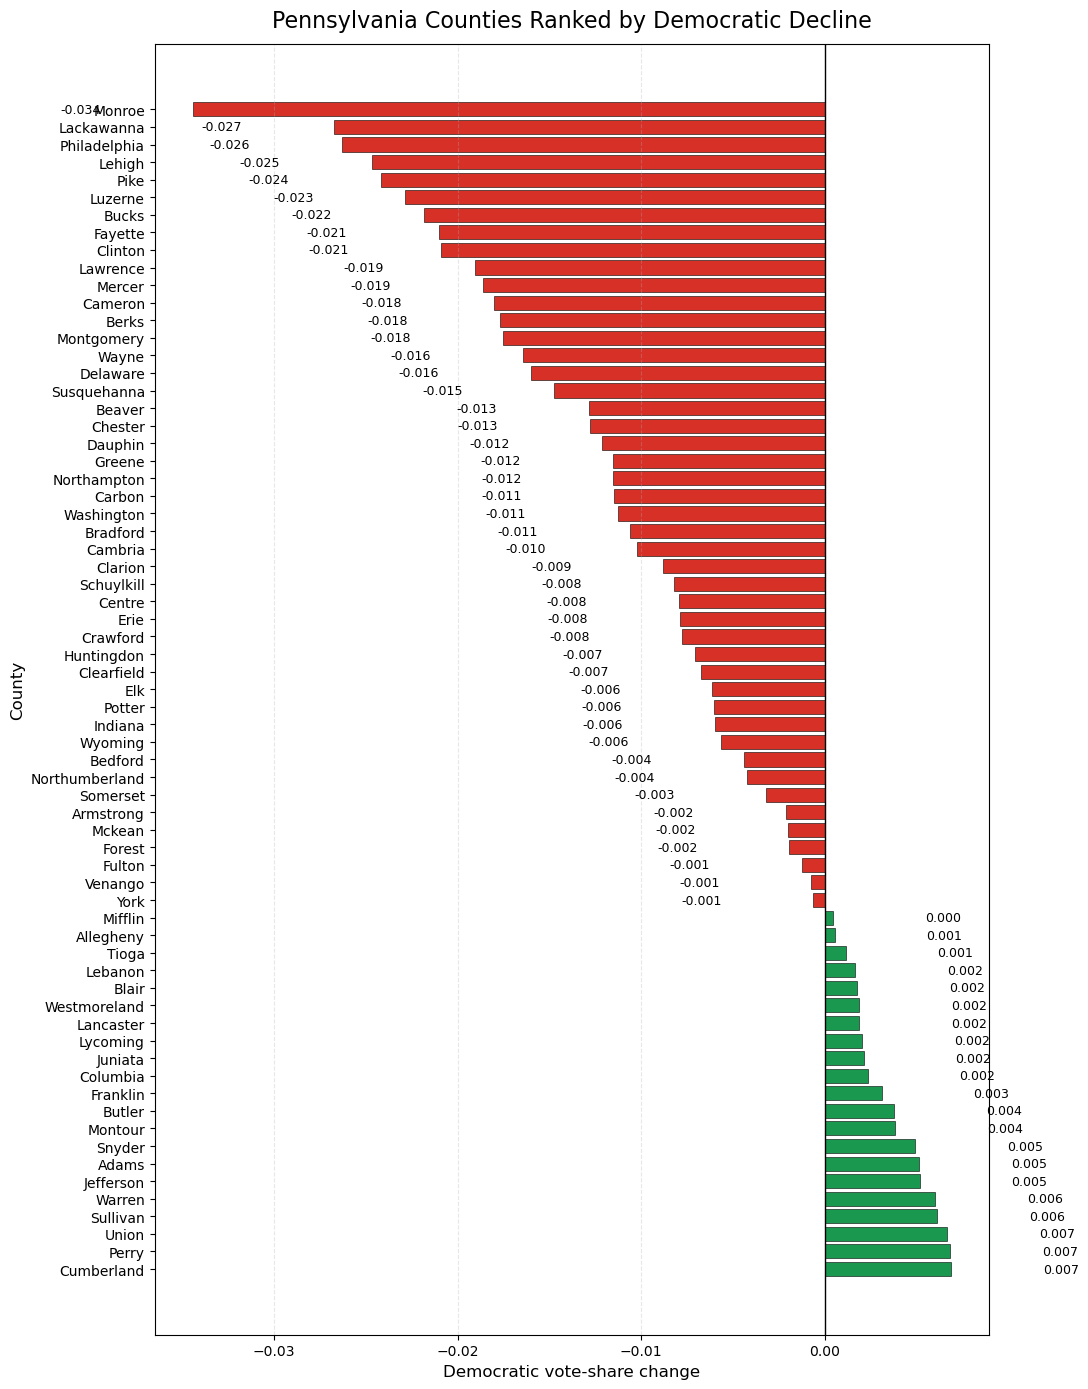

In [11]:
fig, ax = plt.subplots(figsize=(11, 14))

colors = ["#d73027" if v < 0 else "#1a9850" for v in rank_df[shift_col]]

bars = ax.barh(rank_df[county_col], rank_df[shift_col], color=colors, edgecolor="black", linewidth=0.4)

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Democratic vote-share change", fontsize=12)
ax.set_ylabel("County", fontsize=12)
ax.set_title("Pennsylvania Counties Ranked by Democratic Decline", fontsize=16, pad=12)

# Put largest decline at the top
ax.invert_yaxis()

# Add value labels
for bar, val in zip(bars, rank_df[shift_col]):
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    label = f"{val:.3f}"
    if val < 0:
        ax.text(x - 0.005, y, label, va="center", ha="right", fontsize=9, color="black")
    else:
        ax.text(x + 0.005, y, label, va="center", ha="left", fontsize=9, color="black")

ax.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

Path("output").mkdir(exist_ok=True)
fig.savefig("C:/Users/mutch/Democratic_Voter_Shift/output/pa_county_shift_ranked_bar.png", dpi=300, bbox_inches="tight", transparent=True)

### CREATING A TURNOUT-CHANGE MAP FOR COMPARISON ###

**Find the turnout-change variable**

In [12]:
possible_fips = ["countyfips"]
possible_county = ["county"]
possible_turnout = ["turnout_change"]

fips_col = next((c for c in possible_fips if c in df.columns), None)
county_col = next((c for c in possible_county if c in df.columns), None)
turnout_col = next((c for c in possible_turnout if c in df.columns), None)

if turnout_col is None:
    raise ValueError("Could not find a turnout-change column.")
if fips_col is None and county_col is None:
    raise ValueError("Could not find a county identifier column.")

print("Using:", fips_col, county_col, turnout_col)

Using: countyfips county turnout_change


**Clean the merge key**

In [13]:
if fips_col is not None:
    df[fips_col] = df[fips_col].astype(str).str.extract(r"(\d+)")[0]
    df[fips_col] = df[fips_col].str.zfill(5)

if county_col is not None:
    df[county_col] = df[county_col].astype(str).str.lower().str.strip()


**(County boundries already loaded earlier) Read Shapefile and filter Pa.** 

In [14]:
counties = gpd.read_file("pa_county_shp/cb_2023_us_county_500k.shp")
pa = counties[counties["STATEFP"] == "42"].copy()

pa["GEOID"] = pa["GEOID"].astype(str).str.zfill(5)
pa["NAME"] = pa["NAME"].astype(str).str.lower().str.strip()

pa.head()


,STATEFP,COUNTYFP,COUNTYNS,GEOIDFQ,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry
96,42,111,01209188,0500000US42111,42111,somerset,Somerset County,PA,Pennsylvania,06,2784359437,17101197,"POLYGON ((-79.41728 39.85445, -79.39876 39.900..."
97,42,133,01209193,0500000US42133,42133,york,York County,PA,Pennsylvania,06,2342295977,16503209,"POLYGON ((-77.13742 40.06994, -77.08039 40.110..."
233,42,027,01214720,0500000US42027,42027,centre,Centre County,PA,Pennsylvania,06,2867787637,11295681,"POLYGON ((-78.37603 40.7545, -78.37426 40.756,..."
234,42,041,01209176,0500000US42041,42041,cumberland,Cumberland County,PA,Pennsylvania,06,1412792253,12666284,"POLYGON ((-77.62503 40.18999, -77.61466 40.198..."
235,42,035,01214721,0500000US42035,42035,clinton,Clinton County,PA,Pennsylvania,06,2304129979,23182058,"POLYGON ((-78.09338 41.21693, -78.05358 41.273..."


**Merge turnout data with county geometry**

In [15]:
if fips_col is not None:
    merged = pa.merge(df, left_on="GEOID", right_on=fips_col, how="left")
else:
    merged = pa.merge(df, left_on="NAME", right_on=county_col, how="left")

merged[[c for c in ["NAME", "GEOID", turnout_col] if c in merged.columns]].head()


,NAME,GEOID,turnout_change
0,somerset,42111,-0.002395
1,york,42133,-0.013045
2,centre,42027,0.044139
3,cumberland,42041,0.036078
4,clinton,42035,0.016933


**Plot the turnout change map**

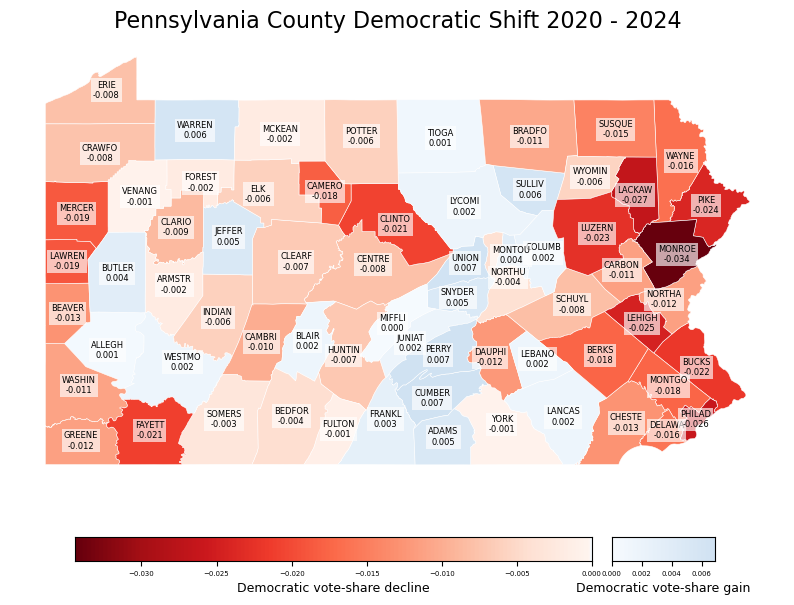

In [18]:
from matplotlib.colors import LinearSegmentedColormap, Normalize
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(10, 12))

if pd.api.types.is_numeric_dtype(merged[shift_col]):
    vmin = merged[shift_col].min()
    vmax = merged[shift_col].max()
    vext = max(abs(vmin), abs(vmax))  # shared extent for both sides

    # One diverging colormap: dark red -> white -> dark blue
    n = 256
    reds_half = plt.cm.Reds_r(np.linspace(0, 1, n))   # dark red (0) -> white (1)
    blues_half = plt.cm.Blues(np.linspace(0, 1, n))   # white (0) -> dark blue (1)
    custom_cmap = LinearSegmentedColormap.from_list(
        "RedWhiteBlue", np.vstack((reds_half, blues_half))
    )

    # Symmetric norm: equal magnitude = equal intensity, regardless of sign
    norm = Normalize(vmin=-vext, vmax=vext)

    merged.plot(
        column=shift_col,
        cmap=custom_cmap,
        norm=norm,
        linewidth=0.4,
        edgecolor="white",
        legend=False,
        ax=ax,
        missing_kwds={
            "color": "lightgrey",
            "edgecolor": "white",
            "hatch": "///",
            "label": "Missing"
        }
    )
    ax.set_title("Pennsylvania County Democratic Shift 2020 - 2024", fontsize=16)
else:
    merged["shift_cat"] = merged[shift_col].astype("category")
    merged.plot(
        column="shift_cat", categorical=True, cmap="Set2",
        linewidth=0.4, edgecolor="white", legend=True, ax=ax,
        missing_kwds={"color": "lightgrey", "edgecolor": "white", "hatch": "///", "label": "Missing"}
    )
    ax.set_title("Pennsylvania County Democratic Shift Category", fontsize=16)

# Create a short county label
if "countyname" in merged.columns:
    name_col = "countyname"
elif "county_name" in merged.columns:
    name_col = "county_name"
elif "county_x" in merged.columns:
    name_col = "county_x"
elif "NAME" in merged.columns:
    name_col = "NAME"
else:
    name_col = None

for idx, row in merged.iterrows():
    if pd.isna(row[shift_col]):
        continue

    pt = row.geometry.representative_point()
    county_label = str(row[name_col]).upper()[:6] if name_col is not None else str(row["NAME"]).upper()[:6]
    value_label = f"{row[shift_col]:.3f}" if pd.api.types.is_numeric_dtype(merged[shift_col]) else str(row[shift_col])

    ax.text(
        pt.x, pt.y, f"{county_label}\n{value_label}",
        ha="center", va="center", fontsize=6, color="black",
        bbox=dict(facecolor="white", alpha=0.65, edgecolor="none", pad=1.5)
    )

ax.set_axis_off()

if pd.api.types.is_numeric_dtype(merged[shift_col]):
    plt.subplots_adjust(bottom=0.12)

    # Size each colorbar segment proportionally to its actual data range,
    # so physical length reflects the real span while the color scale (units per cm) stays identical.
    neg_extent = abs(vmin)
    pos_extent = vmax
    total_extent = neg_extent + pos_extent

    avail_width = 0.62
    gap = 0.02
    left_start = 0.19

    neg_width = avail_width * (neg_extent / total_extent)
    pos_width = avail_width * (pos_extent / total_extent)

    cax_neg = fig.add_axes([left_start, 0.25, neg_width, 0.02])
    cax_pos = fig.add_axes([left_start + neg_width + gap, 0.25, pos_width, 0.02])

    # Sample the SAME shared cmap + norm across each segment's real value range
    neg_vals = np.linspace(vmin, 0, 256).reshape(1, -1)
    pos_vals = np.linspace(0, vmax, 256).reshape(1, -1)

    cax_neg.imshow(neg_vals, aspect="auto", cmap=custom_cmap, norm=norm,
                    extent=[vmin, 0, 0, 1])
    cax_pos.imshow(pos_vals, aspect="auto", cmap=custom_cmap, norm=norm,
                    extent=[0, vmax, 0, 1])

    cax_neg.set_yticks([])
    cax_pos.set_yticks([])
    cax_neg.set_xlabel("Democratic vote-share decline", fontsize=9)
    cax_pos.set_xlabel("Democratic vote-share gain", fontsize=9)
    cax_neg.tick_params(labelsize=5)
    cax_pos.tick_params(labelsize=5)
else:
    plt.tight_layout()

fig.savefig(
    "C:/Users/mutch/Democratic_Voter_Shift/output/pa_county_democratic_shift.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


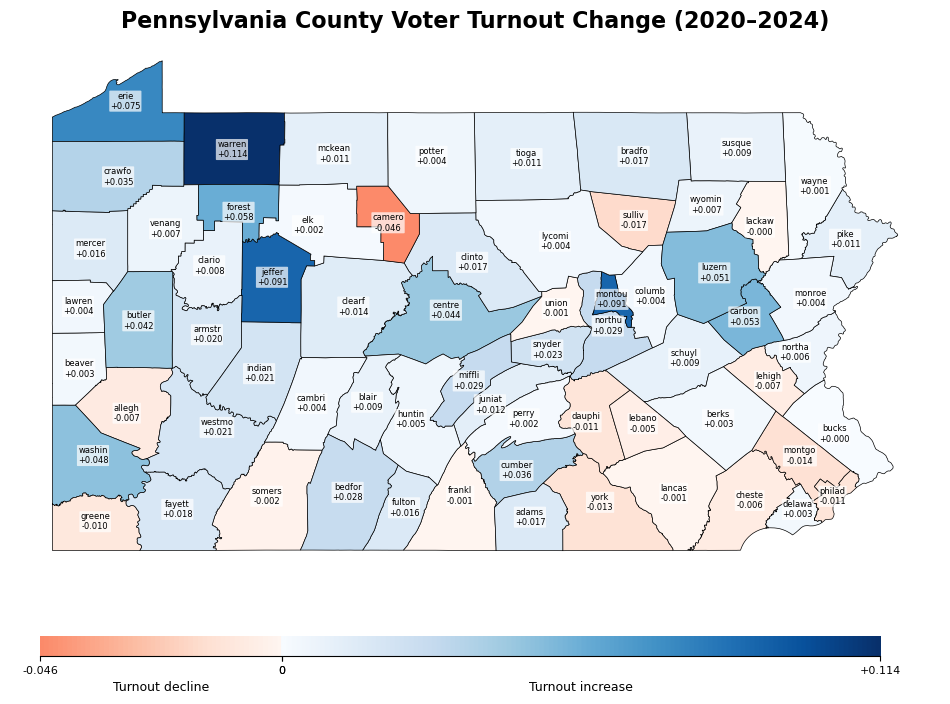

In [35]:
"""
Pennsylvania County Voter Turnout Change (2020-2024)
Single symmetric diverging colorbar, equal color intensity per equal magnitude,
colorbar segment widths proportional to actual data range.

Mirrors the structure of the Democratic vote-share shift map:
- shared symmetric Normalize (not TwoSlopeNorm) so +/-X have identical intensity
- custom diverging colormap: Reds_r (turnout decline) -> Blues (turnout increase)
- single horizontal colorbar built from two imshow segments, widths scaled to
  the true negative/positive extents so the shorter side is visually shorter
  but the color-per-unit scale stays consistent across both sides
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ---------------------------------------------------------------------------
# 0. Column name — point this at your actual turnout-change column
#    e.g. turnout_2024 - turnout_2020, stored in your GeoDataFrame `merged`
# ---------------------------------------------------------------------------
turnout_col = "turnout_change"

# ---------------------------------------------------------------------------
# 1. Data range and shared symmetric norm (equal magnitude -> equal intensity)
# ---------------------------------------------------------------------------
vmin = merged[turnout_col].min()
vmax = merged[turnout_col].max()

vext = max(abs(vmin), abs(vmax))
norm = mcolors.Normalize(vmin=-vext, vmax=vext)

# ---------------------------------------------------------------------------
# 2. Custom diverging colormap: Reds_r (dark at most negative) -> Blues
#    (dark at most positive), stitched at 0
# ---------------------------------------------------------------------------
reds_r = plt.get_cmap("Reds_r")
blues = plt.get_cmap("Blues")

colors_neg = reds_r(np.linspace(0, 1, 128))   # dark red -> near-white toward 0
colors_pos = blues(np.linspace(0, 1, 128))    # near-white -> dark blue away from 0
custom_colors = np.vstack((colors_neg, colors_pos))
custom_cmap = mcolors.LinearSegmentedColormap.from_list("turnout_diverging", custom_colors)

# ---------------------------------------------------------------------------
# 3. Map
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

merged.plot(
    column=turnout_col,
    cmap=custom_cmap,
    norm=norm,
    linewidth=0.5,
    edgecolor="black",
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "black",
        "linewidth": 0.5,
        "hatch": "///",
        "label": "No data",
    },
)

ax.set_title("Pennsylvania County Voter Turnout Change (2020–2024)", fontsize=16, fontweight="bold")
ax.axis("off")

# ---------------------------------------------------------------------------
# 4. County labels (name abbreviation + signed value), same style as before
# ---------------------------------------------------------------------------
for idx, row in merged.iterrows():
    value = row[turnout_col]
    if pd.notna(value):
        point = row["geometry"].representative_point()
        label = f"{str(row['county'])[:6]}\n{value:+.3f}"
        ax.annotate(
            label,
            xy=(point.x, point.y),
            ha="center",
            va="center",
            fontsize=6,
            bbox=dict(boxstyle="round,pad=0.1", facecolor="white", edgecolor="none", alpha=0.7),
        )

# ---------------------------------------------------------------------------
# 5. Single colorbar, two proportional segments (Reds_r side | Blues side)
# ---------------------------------------------------------------------------
plt.subplots_adjust(bottom=0.12)

neg_extent = abs(vmin)
pos_extent = abs(vmax)
total_extent = neg_extent + pos_extent

cbar_left = 0.15
cbar_bottom = 0.15
cbar_height = 0.02
avail_width = 0.70  # total figure-fraction width available for both segments combined

neg_width = avail_width * (neg_extent / total_extent)
pos_width = avail_width * (pos_extent / total_extent)

ax_neg = fig.add_axes([cbar_left, cbar_bottom, neg_width, cbar_height])
ax_pos = fig.add_axes([cbar_left + neg_width, cbar_bottom, pos_width, cbar_height])

# Gradients evaluated under the SAME shared norm as the map, so color
# intensity here matches the map exactly (equal magnitude = equal intensity)
neg_gradient = np.linspace(vmin, 0, 256).reshape(1, -1)
pos_gradient = np.linspace(0, vmax, 256).reshape(1, -1)

ax_neg.imshow(neg_gradient, aspect="auto", cmap=custom_cmap, norm=norm, extent=[vmin, 0, 0, 1])
ax_pos.imshow(pos_gradient, aspect="auto", cmap=custom_cmap, norm=norm, extent=[0, vmax, 0, 1])

for a in (ax_neg, ax_pos):
    a.set_yticks([])
    for spine in ("top", "right", "left"):
        a.spines[spine].set_visible(False)

ax_neg.set_xlim(vmin, 0)
ax_pos.set_xlim(0, vmax)
ax_neg.set_xticks([vmin, 0])
ax_neg.set_xticklabels([f"{vmin:+.3f}", "0"], fontsize=8)
ax_pos.set_xticks([0, vmax])
ax_pos.set_xticklabels(["0", f"{vmax:+.3f}"], fontsize=8)

ax_neg.set_xlabel("Turnout decline", fontsize=9)
ax_pos.set_xlabel("Turnout increase", fontsize=9)

# ---------------------------------------------------------------------------
# 6. Save to PNG, then display
# ---------------------------------------------------------------------------
fig.savefig(
    "C:/Users/mutch/Democratic_Voter_Shift/output/pa_county_turnout_change.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()